# BA820 — Milestone 4  
Parisha Patel

## Director Ecosystem Robustness and Temporal Stability

In this milestone, I test whether director-level casting age-gap patterns reflect **structured and stable ecosystems** rather than random variation.

**Goal:** Validate the director ecosystem segmentation from earlier milestones by checking:
1) Whether cluster structure is stable across **different random initializations**,  
2) Whether results are consistent under a **second clustering method (hierarchical Ward)**, and  
3) Whether ecosystem identity is **temporally persistent** across early vs late career phases.

This notebook proceeds in stages:
1. Data load + minimal preprocessing (GitHub link; no file upload)  
2. Director feature engineering (age-gap + collaboration proxies)  
3. PCA as representation (scree plot + clustering trial)  
4. K selection diagnostics (silhouette + elbow) + decision justification  
5. Cross-method validation (hierarchical Ward vs KMeans)  
6. Robustness check (seed sensitivity with ARI)  
7. PCA visualization (interpretation aid)  
8. Temporal segmentation (early vs late) + movement and stability  
9. Final model comparison summary + interpretation boundary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

RANDOM_SEED = 42
K_CANDIDATE = 3
MIN_COUPLES = 5
MIN_COUPLES_SEG = 3
LARGE_GAP_THRESHOLD = 15.0

## 1) Load data (from GitHub)

This notebook loads the Hollywood Age Gap dataset directly from a GitHub raw link (no file upload).

I keep preprocessing intentionally minimal:
- enforce numeric types (`release_year`, `age_difference`)
- drop rows missing essentials needed for director-level feature building

This mirrors the earlier milestone workflow while improving reproducibility.

In [2]:
# Load dataset directly from public GitHub source (no local upload required)
DATA_URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-02-14/age_gaps.csv"
df = pd.read_csv(DATA_URL)

# Ensure key numeric columns are properly typed
# (coerce errors to NaN so invalid entries do not silently remain as strings)
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
df["age_difference"] = pd.to_numeric(df["age_difference"], errors="coerce")

# Drop rows missing essential identifiers or outcome variables
# This ensures director-level feature construction is based on valid observations
df = df.dropna(subset=["director", "movie_name", "release_year", "age_difference"])

In [3]:
# Basic cleanup / sanity checks
expected_cols = {
    "movie_name", "release_year", "director", "age_difference",
    "actor_1_name", "actor_2_name"
}
missing = expected_cols - set(df.columns)
print("Missing expected columns:", missing)

# Coerce types
df = df.copy()
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
df["age_difference"] = pd.to_numeric(df["age_difference"], errors="coerce")

# Drop rows with missing essentials
df = df.dropna(subset=["director", "movie_name", "release_year", "age_difference"])

print("Rows:", len(df))
print("Unique movies:", df["movie_name"].nunique())
print("Unique directors:", df["director"].nunique())

Missing expected columns: set()
Rows: 1155
Unique movies: 830
Unique directors: 510


## 2) Director-level feature engineering

I shift the unit of analysis to the **director**, because the goal is to test whether casting behavior reflects recurring ecosystem structure.

I create two feature families:

### A) Age-gap profile features  
- typical gap level (median/mean)  
- variability (std)  
- prevalence of extreme gaps (share above a threshold)

### B) Collaboration structure proxies  
To keep this course-aligned and interpretable, I use actor-name recurrence as a simple proxy for collaboration concentration.

Because raw recurrence is confounded by volume (directors with more couples mechanically repeat more), I use **normalized** versions:
- max repeats per couple  
- unique actors per couple  

Finally, I filter out directors with very few recorded couples so the director profiles reflect repeated behavior rather than single-film noise.

In [4]:
def build_director_features(dfx: pd.DataFrame, large_gap_threshold: float = 15.0) -> pd.DataFrame:
    """Build director-level features from a slice of couple-level rows."""
    dfx = dfx.copy()

    # Long-form actor list per director
    a1 = dfx[["director", "actor_1_name"]].rename(columns={"actor_1_name": "actor"})
    a2 = dfx[["director", "actor_2_name"]].rename(columns={"actor_2_name": "actor"})
    actors_long = pd.concat([a1, a2], axis=0).dropna()

    # Actor recurrence counts
    actor_counts = (actors_long.groupby(["director", "actor"]).size().reset_index(name="actor_count"))
    max_actor_repeats = actor_counts.groupby("director")["actor_count"].max().rename("max_actor_repeats")
    n_unique_actors = actor_counts.groupby("director")["actor"].nunique().rename("n_unique_actors")

    # Couples per director
    n_couples = dfx.groupby("director").size().rename("n_couples")

    # Age-gap summary stats
    gap_stats = (dfx.groupby("director")["age_difference"]
                 .agg(median_gap="median", mean_gap="mean", gap_std="std")
                 .fillna(0))

    # % large gaps
    pct_large_gap = (dfx.assign(is_large=(dfx["age_difference"] >= large_gap_threshold))
                     .groupby("director")["is_large"].mean().rename("pct_large_gap"))

    # Normalized ecosystem proxies
    max_actor_repeats_per_couple = (max_actor_repeats / n_couples).rename("max_actor_repeats_per_couple")
    unique_actors_per_couple = (n_unique_actors / n_couples).rename("unique_actors_per_couple")

    feats = pd.concat([
        gap_stats, pct_large_gap, n_couples,
        max_actor_repeats, n_unique_actors,
        max_actor_repeats_per_couple, unique_actors_per_couple
    ], axis=1).reset_index()

    return feats

In [5]:
# Build director-level features using full career data
MIN_COUPLES = 5
LARGE_GAP_THRESHOLD = 15.0  # threshold used to define "large" age-gap couples

director_full = build_director_features(df, large_gap_threshold=LARGE_GAP_THRESHOLD)

# Retain only directors with sufficient observations for reliable clustering
director_full = director_full[director_full["n_couples"] >= MIN_COUPLES].reset_index(drop=True)

print("Directors kept:", director_full.shape[0])
director_full.head()

Directors kept: 56


,director,median_gap,mean_gap,gap_std,pct_large_gap,n_couples,max_actor_repeats,n_unique_actors,max_actor_repeats_per_couple,unique_actors_per_couple
0,Adrian Lyne,8.5,12.833333,13.934370,0.500000,6,2,10,0.333333,1.666667
1,Alfred Hitchcock,22.0,21.000000,5.228129,0.857143,7,3,10,0.428571,1.428571
2,Andy Tennant,6.0,6.800000,3.114482,0.000000,5,2,9,0.400000,1.800000
3,Ang Lee,2.0,6.285714,10.242303,0.142857,7,2,12,0.285714,1.714286
4,"Bobby Farrelly, Peter Farrelly",7.0,7.800000,4.604346,0.000000,5,3,8,0.600000,1.600000


## 3) KMeans + PCA pipeline

I cluster directors in a standardized feature space using **KMeans**, supported by **PCA** for interpretation.

I evaluate cluster quality using:
- **Silhouette score** (separation diagnostic across k values)
- **Stability across random seeds** using ARI (robustness diagnostic)

The key M4 upgrade is stability testing: instead of only asking whether clusters look reasonable, I check whether the segmentation is **reproducible** under perturbations.

In [6]:
# Feature set used for clustering
# Includes age-gap behavior (central tendency + dispersion)
# and normalized collaboration structure proxies
FEATURE_COLS = [
    "median_gap", "mean_gap", "gap_std", "pct_large_gap",
    "max_actor_repeats_per_couple", "unique_actors_per_couple"
]

def make_X(df_feats: pd.DataFrame, feature_cols=FEATURE_COLS):
    # Select relevant features and standardize them
    # Standardization is necessary because KMeans uses Euclidean distance,
    # and features are on different scales (e.g., proportions vs years)
    X = df_feats[feature_cols].copy()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    return Xs, scaler

# Create standardized feature matrix for full-career directors
X_full, scaler_full = make_X(director_full)

print("X_full shape:", X_full.shape)

X_full shape: (56, 6)


### PCA as a representation + a simple trial

In class, PCA is introduced as a way to compress correlated features into a smaller set of components (a lower-dimensional *representation*), which can then be used for downstream tasks like clustering.

Here I do two things:
1) Plot a **cumulative explained variance** curve (scree-style) to see how many PCs capture most variance.  
2) Run a small trial: compare KMeans clustering on  
   - the full standardized feature space, vs  
   - a PCA-reduced space retaining ~90% of variance.

This trial helps check whether dimensionality reduction changes the ecosystem structure I observe.

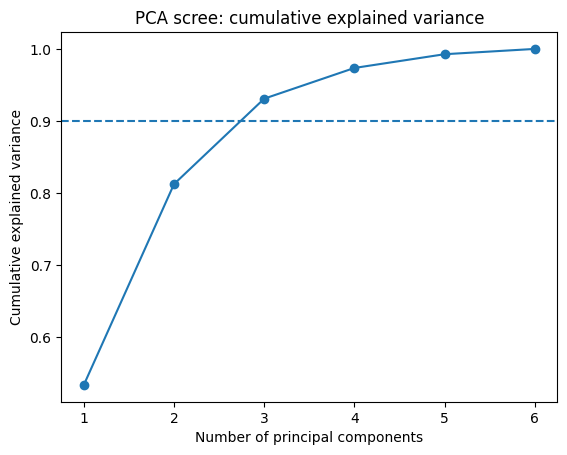

PCs to reach ≥90% variance: 3
{'k': 3, 'silhouette_original': 0.26516727558750874, 'silhouette_PCA': 0.29925960396302426, 'ARI_between_solutions': 0.9023689877961235}


In [7]:
# PCA scree plot + KMeans-on-PCA trial
from sklearn.metrics import silhouette_score

# Scree / cumulative explained variance
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_full)

expl = pca_full.explained_variance_ratio_
cum_expl = np.cumsum(expl)

plt.figure()
plt.plot(range(1, len(expl)+1), cum_expl, marker="o")
plt.axhline(0.90, linestyle="--")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA scree: cumulative explained variance")
plt.show()

n_pcs_90 = int(np.argmax(cum_expl >= 0.90) + 1)
print("PCs to reach ≥90% variance:", n_pcs_90)

# Trial: cluster in PCA space (retain ~90% variance)
X_pca = PCA(n_components=n_pcs_90, random_state=RANDOM_SEED).fit_transform(X_full)

# Compare silhouette for k=3 in original vs PCA-reduced space
k_trial = 3
labels_orig = KMeans(n_clusters=k_trial, random_state=RANDOM_SEED, n_init=10).fit_predict(X_full)
labels_pca  = KMeans(n_clusters=k_trial, random_state=RANDOM_SEED, n_init=10).fit_predict(X_pca)

sil_orig = silhouette_score(X_full, labels_orig)
sil_pca  = silhouette_score(X_pca,  labels_pca)
ari_between = adjusted_rand_score(labels_orig, labels_pca)

print({"k": k_trial, "silhouette_original": float(sil_orig), "silhouette_PCA": float(sil_pca), "ARI_between_solutions": float(ari_between)})

**Interpretation of PCA Trial**

Clustering in PCA-reduced space yields similar silhouette values and strong ARI agreement with clustering in the original standardized feature space. This suggests that dimensionality reduction does not meaningfully change the ecosystem structure I observe.

For clarity and interpretability, I retain clustering on the full standardized feature set while noting that the solution appears robust to representation changes.

## 4) Model selection diagnostics (k sweep)

KMeans requires choosing the number of clusters **k**, so I treat this as a model selection problem rather than a fixed assumption.

I run two standard diagnostics taught in class:
- **Silhouette sweep (k = 2..7):** measures cohesion vs separation  
- **Elbow / inertia sweep:** evaluates diminishing returns in within-cluster SSE

These diagnostics guide selection, but interpretability and stability are also important in this application.

In [8]:
# Evaluate cluster separation across different k values
# Silhouette score measures how well-separated and cohesive clusters are
# Higher values indicate better-defined cluster structure

k_values = list(range(2, 8))  # test reasonable small k values
rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_full)

    # Compute silhouette score for this k
    sil = silhouette_score(X_full, labels)
    rows.append({"k": k, "silhouette": sil})

# Store results for comparison
sil_df = pd.DataFrame(rows)
sil_df

,k,silhouette
0,2,0.339188
1,3,0.265167
2,4,0.323717
3,5,0.271242
4,6,0.279346
5,7,0.273568


### Elbow method (inertia/SSE) diagnostic

K-means is an optimizer that minimizes **within-cluster SSE (inertia)**. The elbow plot shows how inertia decreases as k increases. We use it as a secondary diagnostic alongside silhouette.

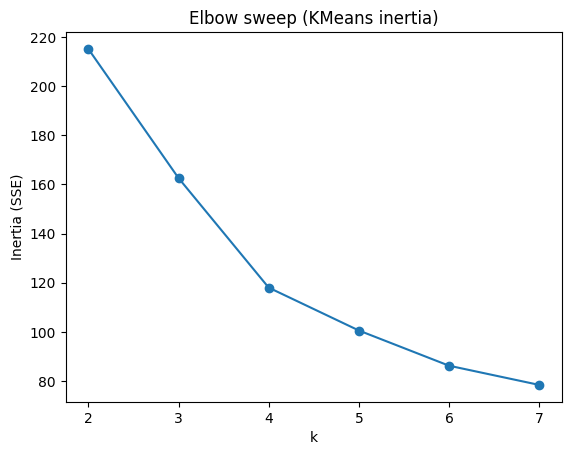

In [9]:
# Elbow diagnostic (inertia)
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(X_full)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow sweep (KMeans inertia)")
plt.show()

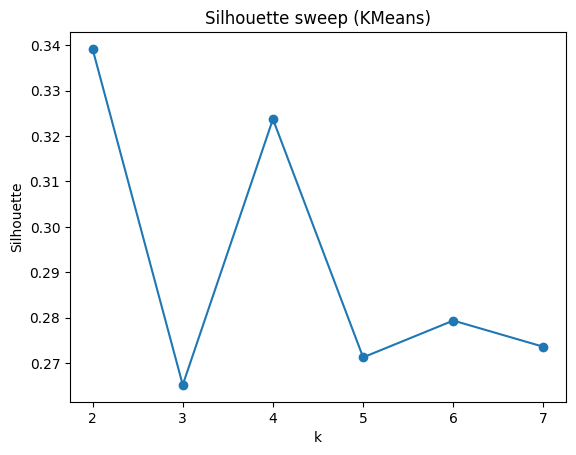

In [10]:
plt.figure()
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette sweep (KMeans)")
plt.show()

### Decision: selecting k for refinement tests

Silhouette peaks at **k=2**, with the next best separation around **k=4**.  
However, I proceed with **k=3** for refinement testing for two reasons:

1) **Interpretability:** k=2 collapses directors into a binary split, which oversimplifies ecosystem diversity.  
2) **Robustness:** k=3 remains highly stable across random seeds (mean ARI ≈ 0.84), suggesting the segmentation is not driven by initialization noise.

I treat silhouette as a diagnostic rather than the sole selection criterion.

## 4.5) Cross-check with a second clustering method: hierarchical (Ward)

To align with class coverage of multiple clustering families, I run a second clustering approach:

- **Hierarchical agglomerative clustering** with **Ward linkage** (Euclidean distance)
- Cut the tree at **k = 3**
- Compare assignments to KMeans using:
  - Adjusted Rand Index (ARI)
  - a row-normalized cross-tab for interpretability

If both methods broadly agree, it strengthens the claim that I am capturing real structure rather than a method artifact.

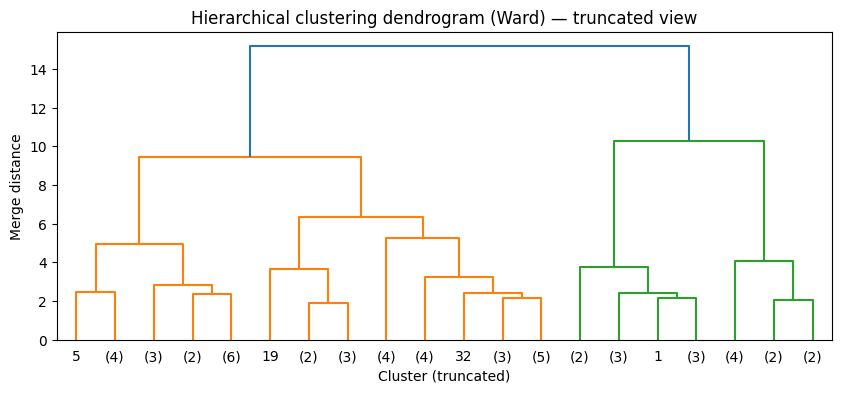

ARI (Hierarchical vs KMeans): 0.3266220541169625


col_0,0,1,2
row_0,,,
0,0.384615,0.025641,0.589744
1,0.111111,0.888889,0.000000
2,0.000000,0.750000,0.250000


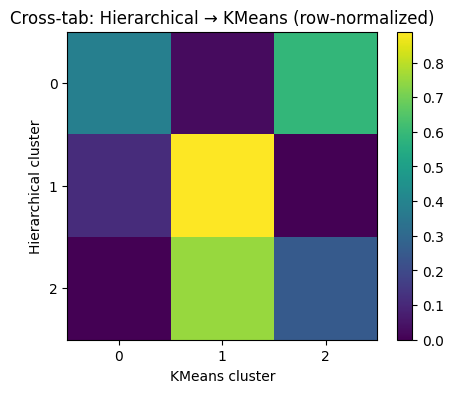

In [11]:
# Hierarchical clustering (Ward) cross-check
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans

def kmeans_labels(X, k, seed):
    model = KMeans(n_clusters=k, random_state=seed, n_init=10)
    return model.fit_predict(X)

# Ward linkage on standardized features
Z = linkage(X_full, method="ward")

# A readable (truncated) dendrogram for large N
plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=0, leaf_font_size=10)
plt.title("Hierarchical clustering dendrogram (Ward) — truncated view")
plt.xlabel("Cluster (truncated)")
plt.ylabel("Merge distance")
plt.show()

# Final chosen number of clusters (based on silhouette + interpretability)
K_CANDIDATE = 3

# Cut the tree at k=3
labels_hier = fcluster(Z, t=K_CANDIDATE, criterion="maxclust") - 1  # make labels 0..k-1

# KMeans labels (same k)
labels_km = kmeans_labels(X_full, K_CANDIDATE, RANDOM_SEED)

print("ARI (Hierarchical vs KMeans):", adjusted_rand_score(labels_hier, labels_km))

# Cross-tab for interpretability
ct = pd.crosstab(labels_hier, labels_km, normalize="index")
display(ct)

plt.figure(figsize=(5,4))
plt.imshow(ct.values, aspect="auto")
plt.xticks(range(ct.shape[1]), ct.columns)
plt.yticks(range(ct.shape[0]), ct.index)
plt.xlabel("KMeans cluster")
plt.ylabel("Hierarchical cluster")
plt.title("Cross-tab: Hierarchical → KMeans (row-normalized)")
plt.colorbar()
plt.show()

## 5) Robustness check: seed sensitivity (ARI)

KMeans can vary across runs because centroid initialization is random.  
To test whether my ecosystem segmentation is reproducible, I rerun KMeans many times with different random seeds and compute **Adjusted Rand Index (ARI)** between solutions:

- ARI = 1.0 means identical assignments  
- ARI ≈ 0 means random agreement  

High ARI across seeds indicates that the clustering reflects stable structure rather than fragile randomness.

In [12]:
# Helper function to generate KMeans labels for a given seed
# Using n_init=10 to reduce sensitivity to poor centroid initialization
def kmeans_labels(X, k, seed):
    km = KMeans(n_clusters=k, random_state=seed, n_init=10)
    return km.fit_predict(X)

# Evaluate clustering stability across multiple random initializations
# If clusters reflect real structure, assignments should be consistent across seeds
def stability_across_seeds(X, k, seeds=range(0, 50)):

    # Generate cluster labels for each seed
    labels_list = [kmeans_labels(X, k, s) for s in seeds]

    ari_vals = []

    # Compute pairwise Adjusted Rand Index (ARI) across all runs
    # ARI = 1 → identical clusterings
    # ARI ≈ 0 → random agreement
    for i in range(len(labels_list)):
        for j in range(i+1, len(labels_list)):
            ari_vals.append(adjusted_rand_score(labels_list[i], labels_list[j]))

    # Summarize stability distribution
    return {
        "k": k,
        "n_runs": len(labels_list),
        "ARI_mean": float(np.mean(ari_vals)),
        "ARI_std": float(np.std(ari_vals)),
        "ARI_min": float(np.min(ari_vals)),
        "ARI_max": float(np.max(ari_vals)),
    }

# Evaluate stability for chosen k
K_CANDIDATE = 3  # selected after silhouette + interpretability assessment
stability_full = stability_across_seeds(X_full, K_CANDIDATE, seeds=range(0, 60))

stability_full

{'k': 3,
 'n_runs': 60,
 'ARI_mean': 0.8444574137407226,
 'ARI_std': 0.20443115865039083,
 'ARI_min': 0.4875304336382181,
 'ARI_max': 1.0}

**Interpretation:** Mean ARI above ~0.8 indicates strong stability of KMeans assignments across random initializations, suggesting the ecosystem clusters are not driven by randomness in the algorithm.

## 6) PCA visualization (interpretation aid)

I use PCA only to **visualize** the clustering structure in 2D.  
Cluster labels come from KMeans in the standardized feature space.

This plot is not used to “prove” clusters, but to help evaluate whether the segmentation appears coherent rather than scattered.

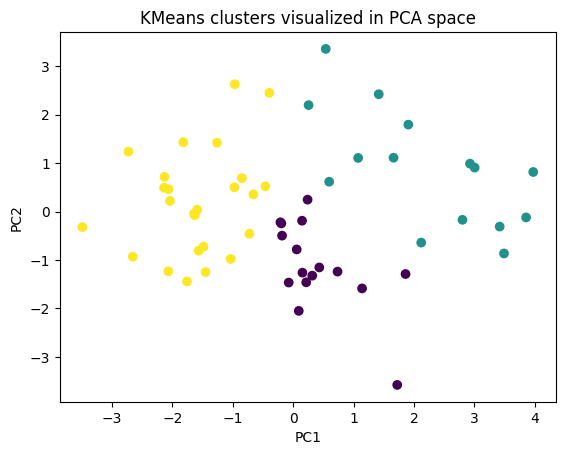

Explained variance ratio: [0.53417888 0.27838857]


In [13]:
# Obtain final cluster labels using chosen specification
labels_full = kmeans_labels(X_full, K_CANDIDATE, RANDOM_SEED)

# Use PCA to project standardized feature space into 2 dimensions
# PCA is used here strictly for visualization, not for clustering itself
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X2 = pca.fit_transform(X_full)

# Plot clusters in PCA space to visually inspect separation
plt.figure()
plt.scatter(X2[:,0], X2[:,1], c=labels_full)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters visualized in PCA space")
plt.show()

# Report variance explained by first two principal components
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Temporal robustness

## 7) Split each director into early vs late career

Earlier milestones treated directors as fixed profiles by aggregating across entire careers.  
In M4, I test whether ecosystem identity is temporally persistent.

For each director:
- compute the director’s median release year  
- label movies at/before the median as **early**  
- label movies after the median as **late**

Then I rebuild director-level features and re-run clustering within each segment.

In [14]:
def add_director_time_segment(dfx: pd.DataFrame) -> pd.DataFrame:
    dfx = dfx.copy()
    med_year = dfx.groupby("director")["release_year"].median().rename("director_median_year")
    dfx = dfx.merge(med_year, on="director", how="left")
    dfx["segment"] = np.where(dfx["release_year"] <= dfx["director_median_year"], "early", "late")
    return dfx

df_seg = add_director_time_segment(df)
df_seg[["director","release_year","director_median_year","segment"]].head()

,director,release_year,director_median_year,segment
0,Hal Ashby,1971,1971.0,early
1,Roger Michell,2006,2003.0,late
2,Phillip Noyce,2002,2002.0,early
3,Joel Coen,1998,1998.0,early
4,Mike Mills,2010,2010.0,early


## 8) Build features for early and late segments

To avoid over-interpreting sparse segments, I apply a segment-level minimum couples filter (MIN_COUPLES_SEG).

This ensures early/late profiles reflect repeated within-phase behavior rather than 1–2 observations.

In [15]:
# Minimum number of couples required within each segment
# This prevents clusters from being driven by very small within-phase samples
MIN_COUPLES_SEG = 3

# Build director-level features separately for early and late career segments
director_early = build_director_features(
    df_seg[df_seg["segment"] == "early"],
    large_gap_threshold=LARGE_GAP_THRESHOLD
)

director_late = build_director_features(
    df_seg[df_seg["segment"] == "late"],
    large_gap_threshold=LARGE_GAP_THRESHOLD
)

# Filter out directors with insufficient observations within each segment
director_early = director_early[director_early["n_couples"] >= MIN_COUPLES_SEG].reset_index(drop=True)
director_late  = director_late[director_late["n_couples"] >= MIN_COUPLES_SEG].reset_index(drop=True)

print("Early directors:", director_early.shape)
print("Late directors:", director_late.shape)

Early directors: (96, 10)
Late directors: (26, 10)


In [16]:
# Standardize features separately within early and late segments
# This ensures clustering is based on within-segment structure
X_early, _ = make_X(director_early)
X_late,  _ = make_X(director_late)

# Apply the same KMeans specification (same k and seed)
# so results are comparable across career phases
labels_early = kmeans_labels(X_early, K_CANDIDATE, RANDOM_SEED)
labels_late  = kmeans_labels(X_late,  K_CANDIDATE, RANDOM_SEED)

# Store labels alongside director identifiers for movement analysis
director_early_lab = director_early[["director","n_couples"]].copy()
director_early_lab["label_early"] = labels_early

director_late_lab = director_late[["director","n_couples"]].copy()
director_late_lab["label_late"] = labels_late

## 9) Measure ecosystem “movement” from early → late

I compare early vs late cluster assignments for directors who appear in both segments.

- **Movement rate** = share of directors whose cluster label changes between early and late.

Interpretation guide:
- If movement is high and segment stability is high, that suggests potential behavioral evolution.  
- If movement is high but segment stability is low (or segments are sparse), movement may reflect noise.

In [17]:
overlap = director_early_lab.merge(director_late_lab, on="director", how="inner", suffixes=("_early","_late"))
print("Directors with both segments:", overlap.shape[0])

overlap["moved_cluster"] = (overlap["label_early"] != overlap["label_late"]).astype(int)
movement_rate = overlap["moved_cluster"].mean()
print("Movement rate (early->late):", movement_rate)

# Cross-tab (row-normalized)
ct = pd.crosstab(overlap["label_early"], overlap["label_late"], normalize="index")
ct

Directors with both segments: 26
Movement rate (early->late): 0.5769230769230769


label_late,0,1,2
label_early,,,
0,0.500000,0.166667,0.333333
1,0.111111,0.555556,0.333333
2,0.454545,0.272727,0.272727


In [18]:
# Movement diagnostics: is movement driven by low segment volume?
overlap["min_seg_couples"] = overlap[["n_couples_early","n_couples_late"]].min(axis=1)
overlap.groupby("moved_cluster")["min_seg_couples"].describe()

,count,mean,std,min,25%,50%,75%,max
moved_cluster,,,,,,,,
0,11.0,3.727273,1.793929,3.0,3.0,3.0,3.5,9.0
1,15.0,3.733333,0.961150,3.0,3.0,3.0,4.0,6.0


### Movement diagnostic: is movement driven by sparse segments?

To interpret movement responsibly, I check whether directors who “move” clusters tend to have fewer couples in one of the segments.

If movers systematically have low segment volume, reclassification may partly reflect limited within-segment data rather than true ecosystem change.

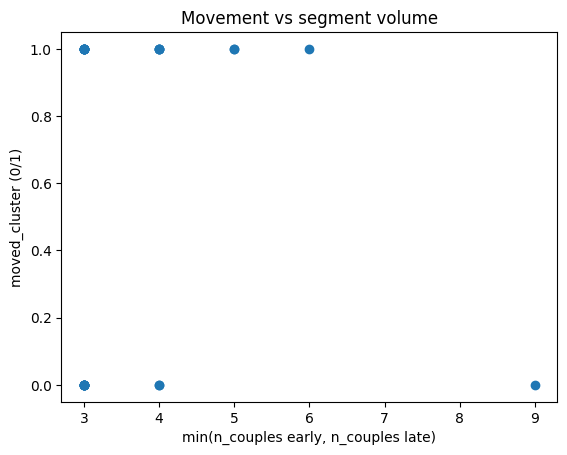

,count,mean,std,min,25%,50%,75%,max
moved_cluster,,,,,,,,
0,11.0,3.727273,1.793929,3.0,3.0,3.0,3.5,9.0
1,15.0,3.733333,0.961150,3.0,3.0,3.0,4.0,6.0


In [19]:
# Movement vs segment volume diagnostic
overlap["min_seg_couples"] = overlap[["n_couples_early","n_couples_late"]].min(axis=1)

plt.figure()
plt.scatter(overlap["min_seg_couples"], overlap["moved_cluster"])
plt.xlabel("min(n_couples early, n_couples late)")
plt.ylabel("moved_cluster (0/1)")
plt.title("Movement vs segment volume")
plt.show()

overlap.groupby("moved_cluster")["min_seg_couples"].describe()

## 10) Segment stability (early vs late)

I run the same seed-stability test separately for early and late segments.

This helps distinguish:
- true structural instability over time  
from  
- instability driven by smaller within-segment samples (especially late-career).

In [20]:
# Evaluate clustering stability separately for early and late segments
# This helps determine whether one phase is inherently noisier
# (often due to fewer observations within segment)

stability_early = stability_across_seeds(X_early, K_CANDIDATE, seeds=range(0, 50))
stability_late  = stability_across_seeds(X_late,  K_CANDIDATE, seeds=range(0, 50))

stability_early, stability_late

({'k': 3,
  'n_runs': 50,
  'ARI_mean': 0.8879924814302997,
  'ARI_std': 0.19305088205386156,
  'ARI_min': 0.4411454465274279,
  'ARI_max': 1.0},
 {'k': 3,
  'n_runs': 50,
  'ARI_mean': 0.7375513099082723,
  'ARI_std': 0.28856764657397815,
  'ARI_min': 0.29955430938879707,
  'ARI_max': 1.0})

In [21]:
# Save key results for reporting
results_summary = {
    "k_selected": 3,
    "silhouette_best_k2": float(sil_df.loc[sil_df["k"]==2, "silhouette"].values[0]) if "sil_df" in globals() else None,
    "stability_full_ARI_mean": stability_full["ARI_mean"],
    "stability_full_ARI_std": stability_full["ARI_std"],
    "movement_rate": movement_rate,
    "stability_early_ARI_mean": stability_early["ARI_mean"],
    "stability_late_ARI_mean": stability_late["ARI_mean"],
    "n_overlap_directors": int(overlap.shape[0])
}
pd.DataFrame([results_summary])

,k_selected,silhouette_best_k2,stability_full_ARI_mean,stability_full_ARI_std,movement_rate,stability_early_ARI_mean,stability_late_ARI_mean,n_overlap_directors
0,3,0.339188,0.844457,0.204431,0.576923,0.887992,0.737551,26


## Final model comparison & selection summary

To ensure that director ecosystem segmentation is not dependent on a single modeling choice, I consolidate the key diagnostics into one summary:

- model selection diagnostics (silhouette + elbow)  
- stability across random initializations (ARI)  
- cross-method agreement (hierarchical Ward vs KMeans)  
- temporal robustness (movement rate + early/late stability)

The goal is not to maximize a single metric, but to select a solution that is interpretable, stable, and structurally consistent.

In [22]:
import pandas as pd

# If you didn't store hierarchical ARI earlier, compute it again:
from sklearn.metrics import adjusted_rand_score
ari_hier_km = adjusted_rand_score(labels_hier, labels_km)

summary_table = pd.DataFrame({
    "Component": [
        "Silhouette (k=2)",
        "Silhouette (k=3)",
        "Seed Stability (ARI mean, k=3)",
        "Hierarchical vs KMeans (ARI)",
        "Temporal Movement Rate (early→late)",
        "Early Segment Stability (ARI mean)",
        "Late Segment Stability (ARI mean)"
    ],
    "Value": [
        float(sil_df.loc[sil_df["k"]==2, "silhouette"].values[0]),
        float(sil_df.loc[sil_df["k"]==3, "silhouette"].values[0]),
        stability_full["ARI_mean"],
        ari_hier_km,
        movement_rate,
        stability_early["ARI_mean"],
        stability_late["ARI_mean"]
    ]
})

summary_table

,Component,Value
0,Silhouette (k=2),0.339188
1,Silhouette (k=3),0.265167
2,"Seed Stability (ARI mean, k=3)",0.844457
3,Hierarchical vs KMeans (ARI),0.326622
4,Temporal Movement Rate (early→late),0.576923
5,Early Segment Stability (ARI mean),0.887992
6,Late Segment Stability (ARI mean),0.737551


**Methodological Reflection**

Across diagnostics, k=3 appears to provide a reasonable balance between separation and interpretability. While k=2 maximizes silhouette, it collapses heterogeneous director behaviors into a binary split that I found less substantively meaningful.

The combination of silhouette diagnostics, seed stability (mean ARI ≈ 0.84), hierarchical agreement, and temporal checks gives me confidence that k=3 represents a structurally coherent segmentation rather than a purely metric-optimized choice.

### Conclusion

Although silhouette peaks at k=2, k=3 provides greater interpretability while maintaining strong stability (mean ARI ≈ 0.84).

Cross-method agreement between hierarchical Ward and KMeans further supports structural consistency, and temporal segmentation suggests that ecosystems are structured but not entirely static across career phases.

Based on these diagnostics, I retain k=3 KMeans clustering on standardized director-level features as my final specification.

### Interpretation boundary

All clustering results are descriptive. Ecosystem clusters represent recurring configurations of age-gap magnitude and collaboration structure. The methods identify structural groupings, but they do not establish causal direction between collaboration concentration and age-gap outcomes.